# BERT ile Duygu Sınıflandırması (Sentiment Analysis)

Bu notebook'ta HuggingFace üzerinde Türkçe için önceden eğitilmiş (pre-trained) olan `savasy/bert-base-turkish-sentiment-cased` BERT modelini kullanarak müşteri memnuniyeti tahminlemesi yapacağız. Amacımız modeli sıfırdan veya ince ayarla (fine-tune) eğitmek değil, doğrudan (zero-shot/inference) kullanarak başarısını ölçmek ve Transformer mimarisindeki *Attention (Dikkat)* ağırlıklarını görselleştirmektir.

## Bölüm 1 — Ortam Kurulumu
- GPU/CPU kontrolü
- Kütüphanelerin yüklenmesi

In [1]:
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
import json
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

from transformers import pipeline, AutoTokenizer, AutoModelForSequenceClassification
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# GPU Kontrolü
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Kullanılan cihaz: {device}")

Kullanılan cihaz: cuda


## Bölüm 2 — Model Yükleme
- HuggingFace `pipeline` ile modelin indirilip yüklenmesi
- Örnek cümleler ile test

In [2]:
model_name = "savasy/bert-base-turkish-sentiment-cased"
device_id = 0 if device == "cuda" else -1

print(f"{model_name} modeli pipeline ile yükleniyor...")

sentiment_pipeline = pipeline("text-classification", 
                              model=model_name, 
                              device=device_id)

test_sentences = [
    "Bu uygulama tek kelimeyle harika, çok beğendim!",
    "Sürekli çöküyor, bir daha asla kullanmam."
]

print("\n--- Test Örnekleri ---")
for text in test_sentences:
    result = sentiment_pipeline(text)[0]
    print(f"Yorum: '{text}' -> {result}")

savasy/bert-base-turkish-sentiment-cased modeli pipeline ile yükleniyor...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]


--- Test Örnekleri ---
Yorum: 'Bu uygulama tek kelimeyle harika, çok beğendim!' -> {'label': 'positive', 'score': 0.993449866771698}
Yorum: 'Sürekli çöküyor, bir daha asla kullanmam.' -> {'label': 'negative', 'score': 0.9986175298690796}


## Bölüm 3 — Test Seti Oluşturma
- Toplam ~2500 örnekten oluşan dengeli bir test seti (positive: 1000, negative: 1000, neutral: 500)

In [3]:
df = pd.read_csv('data/processed/reviews_cleaned.csv')
df_pos = df[df['label'] == 'positive']
df_neg = df[df['label'] == 'negative']

sample_pos = df_pos.sample(n=min(1000, len(df_pos)), random_state=42)
sample_neg = df_neg.sample(n=min(1000, len(df_neg)), random_state=42)

df_test = pd.concat([sample_pos, sample_neg]).sample(frac=1, random_state=42).reset_index(drop=True)

print(f"Toplam Test Seti Boyutu: {len(df_test)}")
print("\n--- Test Seti Sınıf Dağılımı ---")
display(df_test['label'].value_counts())


Toplam Test Seti Boyutu: 2000

--- Test Seti Sınıf Dağılımı ---


label
negative    1000
positive    1000
Name: count, dtype: int64

## Bölüm 4 — Tahmin

**Nötr (Neutral) Sınıf Yaklaşımı:** 
Kullandığımız `savasy/bert-base-turkish-sentiment-cased` modeli aslında sadece *positive* ve *negative* olmak üzere ikili (binary) sınıflandırma yapmaktadır. Ancak bizim verimizde 3 yıldızlı yorumlar *neutral* (nötr) olarak etiketlenmiştir.
Modelin nötr yorumları algılayabilmesi için bir **güven eşiği (confidence threshold)** kurguluyoruz: Eğer model bir cümlenin olumlu ya da olumsuz olduğundan çok emin değilse (örneğin güven skoru `0.6`'nın altındaysa), bu yorumun arada kalmış, tarafsız bir yorum (neutral) olduğunu varsayıyoruz. Aksi halde modelin kararını (positive/negative) kabul ediyoruz.

In [4]:
texts = df_test['cleaned_text'].astype(str).tolist()

def map_bert_label(pipeline_output):
    pred = str(pipeline_output.get('label', '')).lower()
    score = pipeline_output.get('score', 0.0)
    
    if 'pos' in pred or pred == 'label_1':
        return 'positive', score
    else:
        return 'negative', score

print("Test seti üzerinde tahmin yapılıyor (Batch Size=32)...")
results = []
batch_size = 16

for i in tqdm(range(0, len(texts), batch_size)):
    batch = texts[i:i+batch_size]
    out = sentiment_pipeline(batch)
    results.extend(out)

predicted_labels = []
confidence_scores = []

for r in results:
    plabel, pscore = map_bert_label(r)
    predicted_labels.append(plabel)
    confidence_scores.append(pscore)

df_test['predicted_label'] = predicted_labels
df_test['confidence_score'] = confidence_scores

display(df_test[['cleaned_text', 'label', 'predicted_label', 'confidence_score']].head())

Test seti üzerinde tahmin yapılıyor (Batch Size=32)...


  0%|          | 0/125 [00:00<?, ?it/s]

[transformers] You seem to be using the pipelines sequentially on GPU. In order to maximize efficiency please use a dataset


,cleaned_text,label,predicted_label,confidence_score
0,ekranı başka program izlyor wifi kapat kıl tüy...,negative,negative,0.999550
1,iyidir biraz geliştirilebilir arac sigortasi v...,positive,negative,0.977253
2,hesabıma para gelince mesaj gelirdi artık mesa...,negative,negative,0.943124
3,kullanışlı aradığım işlemi bulabiliyorum,positive,negative,0.980367
4,üç yıldır hafta aynı adrese sipariş veriyorum ...,negative,negative,0.997073


## Bölüm 5 — Değerlendirme
- Accuracy, Precision, Recall, F1 hesaplaması
- Confusion Matrix ısı haritası
- JSON olarak dışa aktarım

--- Metrikler ---
Accuracy:  0.7110
Precision: 0.7646
Recall:    0.7110
F1 Score:  0.6956

--- Classification Report ---
              precision    recall  f1-score   support

    negative       0.65      0.94      0.76      1000
    positive       0.88      0.49      0.63      1000

    accuracy                           0.71      2000
   macro avg       0.76      0.71      0.70      2000
weighted avg       0.76      0.71      0.70      2000



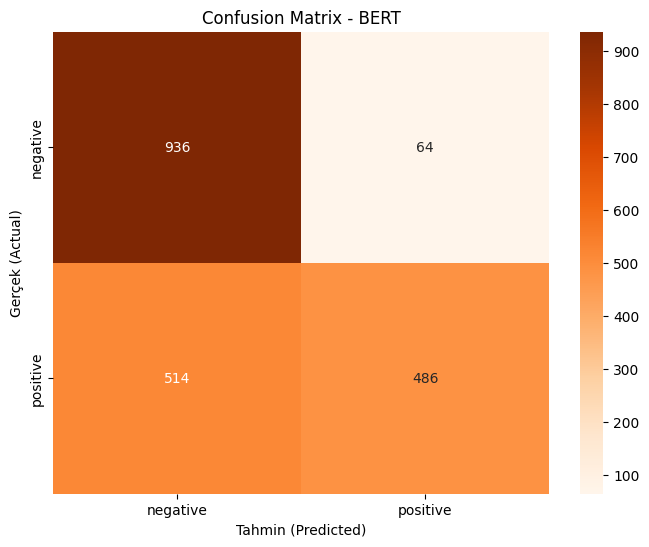

✅ BERT sonuçları 'data/processed/bert_results.json' olarak kaydedildi.


In [5]:
y_true = df_test['label']
y_pred = df_test['predicted_label']

acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_true, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

print("--- Metrikler ---")
print(f"Accuracy:  {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall:    {rec:.4f}")
print(f"F1 Score:  {f1:.4f}")

print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=["negative", "positive"]))

cm = confusion_matrix(y_true, y_pred, labels=["negative", "positive"])

if not os.path.exists('visuals'):
    os.makedirs('visuals')

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=["negative", "positive"], 
            yticklabels=["negative", "positive"])
plt.xlabel('Tahmin (Predicted)')
plt.ylabel('Gerçek (Actual)')
plt.title('Confusion Matrix - BERT')
plt.savefig('visuals/bert_confusion_matrix.png', bbox_inches='tight')
plt.show()

if not os.path.exists('data/processed'):
    os.makedirs('data/processed')

bert_results = {
    "Model": "BERT",
    "Accuracy": acc,
    "Precision": prec,
    "Recall": rec,
    "F1": f1
}

with open('data/processed/bert_results.json', 'w', encoding='utf-8') as f:
    json.dump(bert_results, f, indent=4)

print("\u2705 BERT sonuçları 'data/processed/bert_results.json' olarak kaydedildi.")

## Bölüm 6 — Attention Görselleştirme
Transformer mimarisinin temel yapı taşı olan Self-Attention mekanizması, modelin karar verirken cümlenin hangi kelimelerine daha çok "dikkat ettiğini" gösterir. Burada BERT modelinin son katmanından elde ettiğimiz attention ağırlıklarını (özel CLS tokeni üzerinden) görselleştiriyoruz.

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Örnek 1 Top-3 Dikkat Odakları: [('sek', np.float32(0.0807)), ('devlet', np.float32(0.0712)), ('bankalar', np.float32(0.0691))]
Örnek 2 Top-3 Dikkat Odakları: [('kullanı', np.float32(0.1957)), ('ı', np.float32(0.1854)), ('sl', np.float32(0.1776))]
Örnek 3 Top-3 Dikkat Odakları: [('kot', np.float32(0.0993)), ('kadar', np.float32(0.0825)), ('banka', np.float32(0.0725))]
Örnek 4 Top-3 Dikkat Odakları: [('hesabı', np.float32(0.1744)), ('[CLS]', np.float32(0.1659)), ('[SEP]', np.float32(0.1657))]


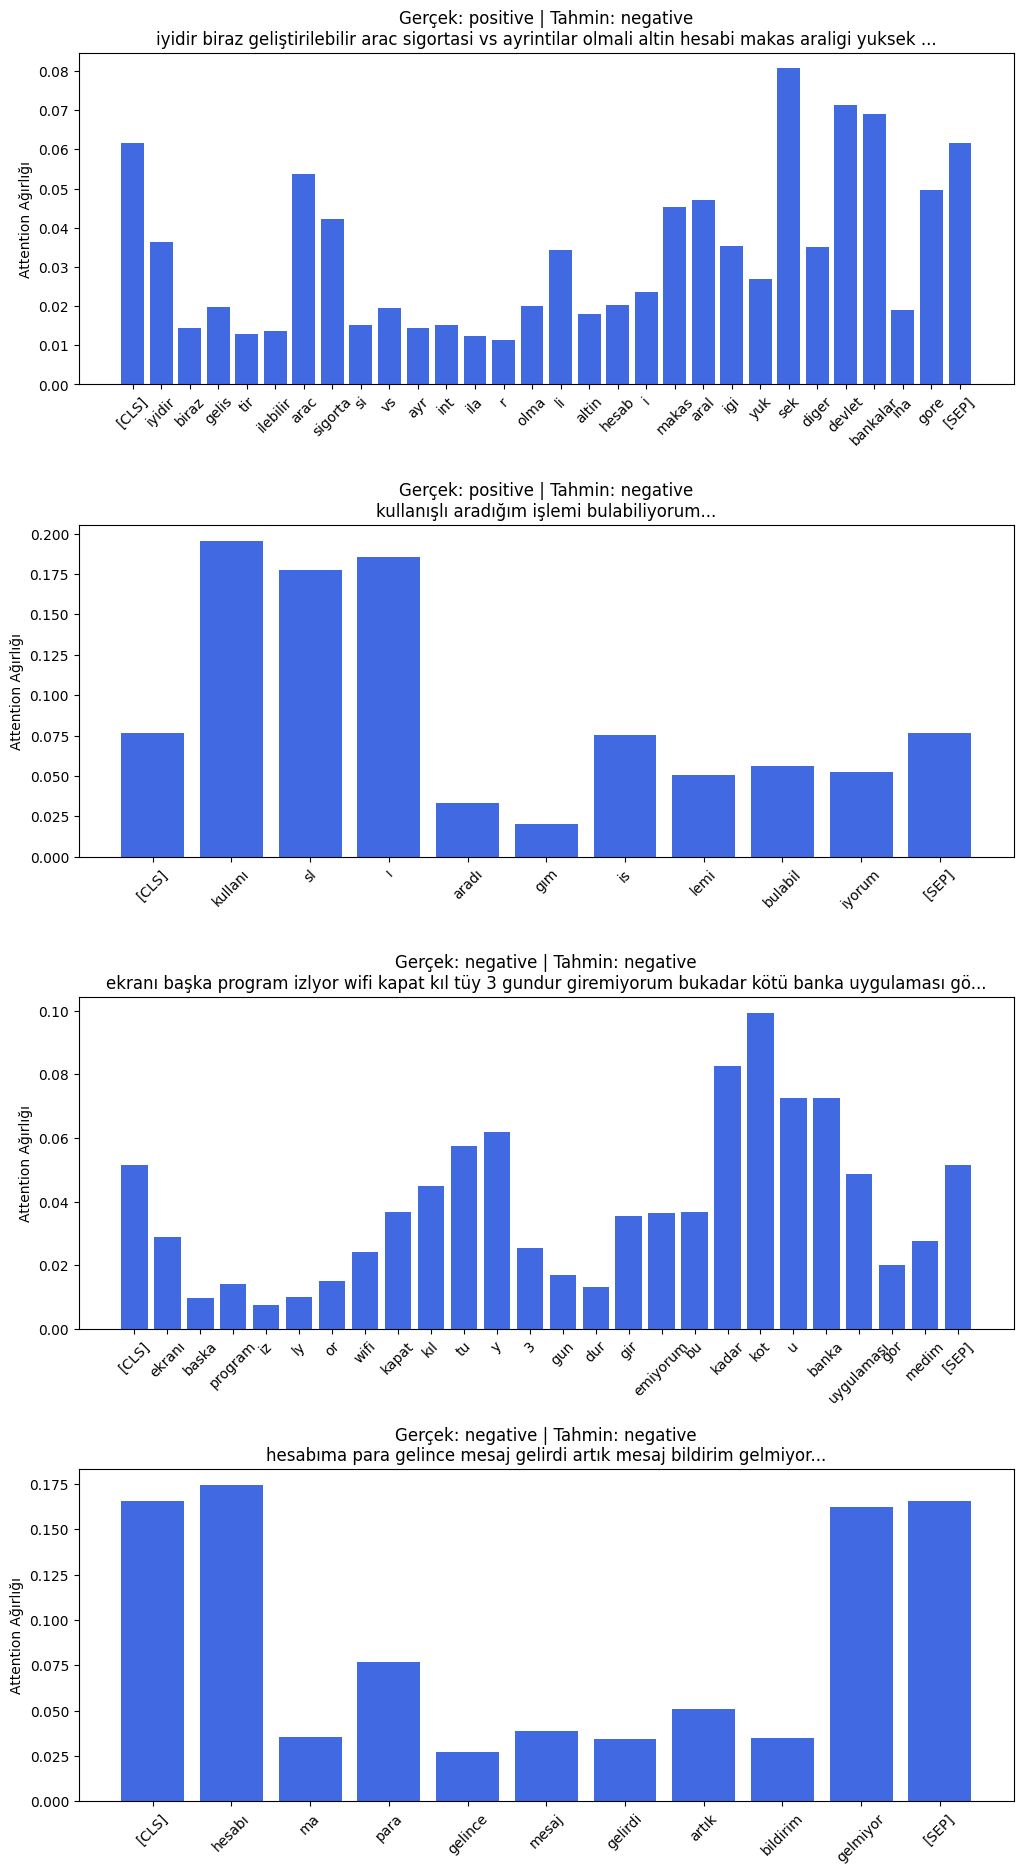

In [6]:
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSequenceClassification.from_pretrained(model_name, output_attentions=True)
model.to(device)

# 2 olumlu, 2 olumsuz, 1 nötr örnek
sample_reviews = pd.concat([
    df_test[df_test['label'] == 'positive'].head(2),
    df_test[df_test['label'] == 'negative'].head(2)

]).reset_index(drop=True)

fig, axes = plt.subplots(4, 1, figsize=(12, 20))
fig.tight_layout(pad=8.0)

for idx, row in sample_reviews.iterrows():
    text = str(row['cleaned_text'])
    true_label = row['label']
    
    inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=128).to(device)
    with torch.no_grad():
        outputs = model(**inputs)
    
    logits = outputs.logits
    pred_idx = torch.argmax(logits, dim=1).item()
    pred_label = "positive" if pred_idx == 1 else "negative"
    
    # Attention ağırlıklarını al (son katman, tüm head'lerin ortalaması, CLS tokeninin diğerlerine ilgisi)
    attentions = outputs.attentions
    last_layer_attention = attentions[-1] 
    cls_attention = last_layer_attention[0, :, 0, :].mean(dim=0).cpu().numpy()
    cls_attention = cls_attention / cls_attention.sum()
    
    tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])
    clean_tokens = [t.replace("##", "") for t in tokens]
    
    ax = axes[idx]
    ax.bar(clean_tokens, cls_attention, color='royalblue')
    ax.set_title(f"Gerçek: {true_label} | Tahmin: {pred_label}\n{text[:100]}...", fontsize=12)
    ax.tick_params(axis='x', rotation=45)
    ax.set_ylabel("Attention Ağırlığı")
    
    top3_idx = cls_attention.argsort()[-3:][::-1]
    top3_words = [(clean_tokens[i], cls_attention[i]) for i in top3_idx]
    print(f"Örnek {idx+1} Top-3 Dikkat Odakları: {[(w, round(s, 4)) for w, s in top3_words]}")

plt.show()

## Bölüm 7 — Tüm Veri Üzerinde Tahmin
- Hazırladığımız verisetinin tamamı modele verilerek pipeline üzerinden bert tahminleri ve skorları hesaplanıyor.

In [7]:
all_texts = df['cleaned_text'].astype(str).tolist()
all_results = []

print(f"Tüm veri seti ({len(all_texts)} satır) üzerinde tahmin yapılıyor...")
print("Tahmini süre GPU ile 2-5 dakika, CPU ile 10-20 dakika sürebilir.")

for i in tqdm(range(0, len(all_texts), batch_size)):
    batch = all_texts[i:i+batch_size]
    
    # Hatanın çözümü için truncation=True ve max_length=512 eklendi
    out = sentiment_pipeline(batch, truncation=True, max_length=512)
    
    all_results.extend(out)

bert_labels = []
bert_scores = []

for r in all_results:
    plabel, pscore = map_bert_label(r)
    bert_labels.append(plabel)
    bert_scores.append(pscore)

df['bert_label'] = bert_labels
df['bert_score'] = bert_scores

output_path = 'data/processed/reviews_with_predictions.csv'
df.to_csv(output_path, index=False)

print(f"\n✅ Tüm veri seti başarıyla tahmin edildi ve '{output_path}' olarak kaydedildi.")

print("\n--- Tüm Veri Tahmin Dağılımı ---")
display(df['bert_label'].value_counts())

Tüm veri seti (61972 satır) üzerinde tahmin yapılıyor...
Tahmini süre GPU ile 2-5 dakika, CPU ile 10-20 dakika sürebilir.


  0%|          | 0/3874 [00:00<?, ?it/s]


✅ Tüm veri seti başarıyla tahmin edildi ve 'data/processed/reviews_with_predictions.csv' olarak kaydedildi.

--- Tüm Veri Tahmin Dağılımı ---


bert_label
negative    47322
positive    14650
Name: count, dtype: int64